In [1]:
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
# Generate homework completion times (in minutes)
# We'll use lognormal since time spent often has a longer right tail 
# (some students take much longer than others)
homework_times = stats.lognorm.rvs(s=0.5, scale=30, size=100)


In [3]:
# First, let's understand what completion times are typical
print("Understanding Homework Times:")
print(f"Average completion time: {stats.tmean(homework_times):.1f} minutes")

Understanding Homework Times:
Average completion time: 34.5 minutes


In [4]:
# Let's find how long we should tell students the homework will take
# We'll use percentiles to give a realistic range
time_ranges = stats.scoreatpercentile(homework_times, [25, 50, 75])
print("\nTypical Time Ranges:")
print(f"Quick students finish in: {time_ranges[0]:.1f} minutes")
print(f"Typical students take: {time_ranges[1]:.1f} minutes")
print(f"Slower students need: {time_ranges[2]:.1f} minutes")


Typical Time Ranges:
Quick students finish in: 22.5 minutes
Typical students take: 29.6 minutes
Slower students need: 45.2 minutes


In [5]:
# What if we want to know the probability a student will finish in under 45 minutes?
# We can fit a distribution to our data and use it to calculate this
shape, loc, scale = stats.lognorm.fit(homework_times)
prob_under_45 = stats.lognorm.cdf(45, shape, loc, scale)
print(f"\nProbability of finishing under 45 minutes: {prob_under_45:.1%}")



Probability of finishing under 45 minutes: 77.8%


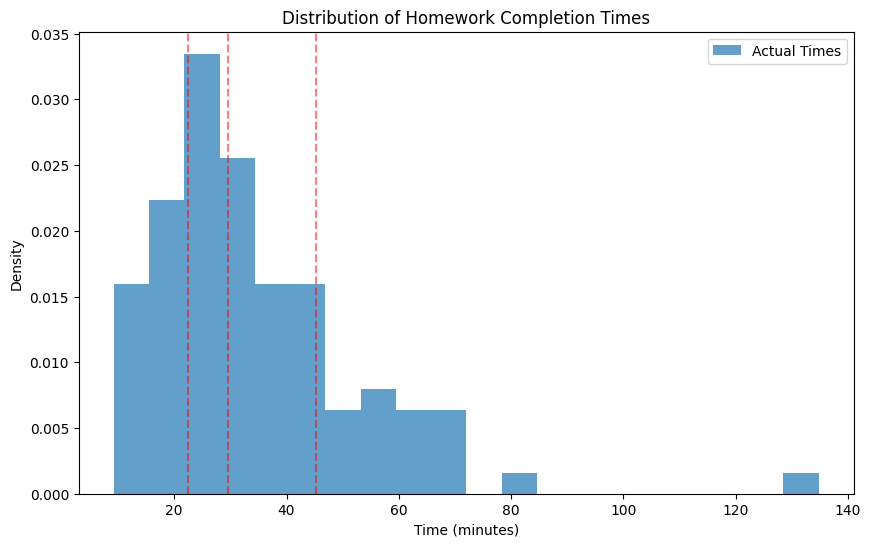

In [6]:
# Visualize the distribution of homework times
plt.figure(figsize=(10, 6))
plt.hist(homework_times, bins=20, density=True, alpha=0.7, 
         label='Actual Times')

# Add markers for typical ranges
for time in time_ranges:
    plt.axvline(time, color='red', linestyle='--', alpha=0.5)

plt.title('Distribution of Homework Completion Times')
plt.xlabel('Time (minutes)')
plt.ylabel('Density')
plt.legend()